# Testing
### Todesfälle nach aggregierter Todesursache, seit 1974
Datum: 19.12.2025

Diese Daten beinhalten aggregierte Todesursachen. Die Todesursachen stammen vom Bundesamt für Statistik und wurden mit den Daten des Bevölkerungsregisters der Stadt Zürich verknüpft.

Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_bevreg_todesursache_seit1974_od3100

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bevreg_todesursache_seit1974_od3100

**Importiere die notwendigen Packages**

In [47]:
#pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [48]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [49]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [50]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [51]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [52]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [53]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [54]:
package_name = "bfs_bevreg_todesursache_seit1974_od3100"

In [55]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV310OD3100"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bevreg_todesursache_seit1974_od3100/download/BEV310OD3100.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bevreg_todesursache_seit1974_od3100 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_bevreg_todesursache_seit1974_od3100 

data_source: web


In [56]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1974-01-01 00:00:00,1975-01-01 00:00:00
TodesursacheSpezSort_noDM,1200,1200
TodesursacheSpezLang_noDM,Alle übrigen Todesursachen,Alle übrigen Todesursachen
TodesursacheSpezCd_noDM,1200,1200
AnzSterWir,642,516


Berechne weitere Attribute falls notwendig

In [57]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr              datetime64[ns]
TodesursacheSpezSort_noDM             int64
TodesursacheSpezLang_noDM            object
TodesursacheSpezCd_noDM               int64
AnzSterWir                          float64
StichtagDatJahr_str                  object
Jahr                         datetime64[ns]
Jahr_end                     datetime64[ns]
Jahr_nbr                              int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [58]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1974 und ein Maximumjahr von 2024


### Einfache Datentests

In [59]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 306 entries, 305 to 153
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   StichtagDatJahr            306 non-null    datetime64[ns]
 1   TodesursacheSpezSort_noDM  306 non-null    int64         
 2   TodesursacheSpezLang_noDM  306 non-null    object        
 3   TodesursacheSpezCd_noDM    306 non-null    int64         
 4   AnzSterWir                 285 non-null    float64       
 5   StichtagDatJahr_str        306 non-null    object        
 6   Jahr                       306 non-null    datetime64[ns]
 7   Jahr_end                   306 non-null    datetime64[ns]
 8   Jahr_nbr                   306 non-null    int32         
dtypes: datetime64[ns](3), float64(1), int32(1), int64(2), object(2)
memory usage: 62.7 KB


In [60]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 306 rows (observations) and 9 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [61]:
data2betested.describe()

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,AnzSterWir,Jahr,Jahr_end,Jahr_nbr
count,306,306,306,285,306,306,306
mean,1999-01-01 02:49:24.705882368,667,667,689,1999-01-01 02:49:24.705882368,1999-12-31 08:56:28.235294080,1999
min,1974-01-01 00:00:00,200,200,152,1974-01-01 00:00:00,1974-12-31 00:00:00,1974
25%,1986-01-01 00:00:00,400,400,237,1986-01-01 00:00:00,1986-12-31 00:00:00,1986
50%,1999-01-01 00:00:00,550,550,640,1999-01-01 00:00:00,1999-12-31 00:00:00,1999
75%,2012-01-01 00:00:00,1100,1100,961,2012-01-01 00:00:00,2012-12-31 00:00:00,2012
max,2024-01-01 00:00:00,1200,1200,2275,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,364,364,528,NaN,NaN,15


Welches sind die Quartiere ohne Werte bei BEW?

In [62]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
122,1994-01-01,400,Demenz,400,NaN,1994-01-01,1994-01-01,1994-12-31,1994
121,1993-01-01,400,Demenz,400,NaN,1993-01-01,1993-01-01,1993-12-31,1993
120,1992-01-01,400,Demenz,400,NaN,1992-01-01,1992-01-01,1992-12-31,1992
119,1991-01-01,400,Demenz,400,NaN,1991-01-01,1991-01-01,1991-12-31,1991
118,1990-01-01,400,Demenz,400,NaN,1990-01-01,1990-01-01,1990-12-31,1990
117,1989-01-01,400,Demenz,400,NaN,1989-01-01,1989-01-01,1989-12-31,1989
116,1988-01-01,400,Demenz,400,NaN,1988-01-01,1988-01-01,1988-12-31,1988
115,1987-01-01,400,Demenz,400,NaN,1987-01-01,1987-01-01,1987-12-31,1987
114,1986-01-01,400,Demenz,400,NaN,1986-01-01,1986-01-01,1986-12-31,1986
113,1985-01-01,400,Demenz,400,NaN,1985-01-01,1985-01-01,1985-12-31,1985


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [63]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [64]:
data2betested.index.year.unique()

Index([1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988,
       1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [65]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [66]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,TodesursacheSpezSort_noDM,TodesursacheSpezCd_noDM,AnzSterWir,Jahr_nbr
count,306,306,285,306
mean,667,667,689,"1,999"
std,364,364,528,15
min,200,200,152,"1,974"
25%,400,400,237,"1,986"
50%,550,550,640,"1,999"
75%,"1,100","1,100",961,"2,012"
max,"1,200","1,200","2,275","2,024"


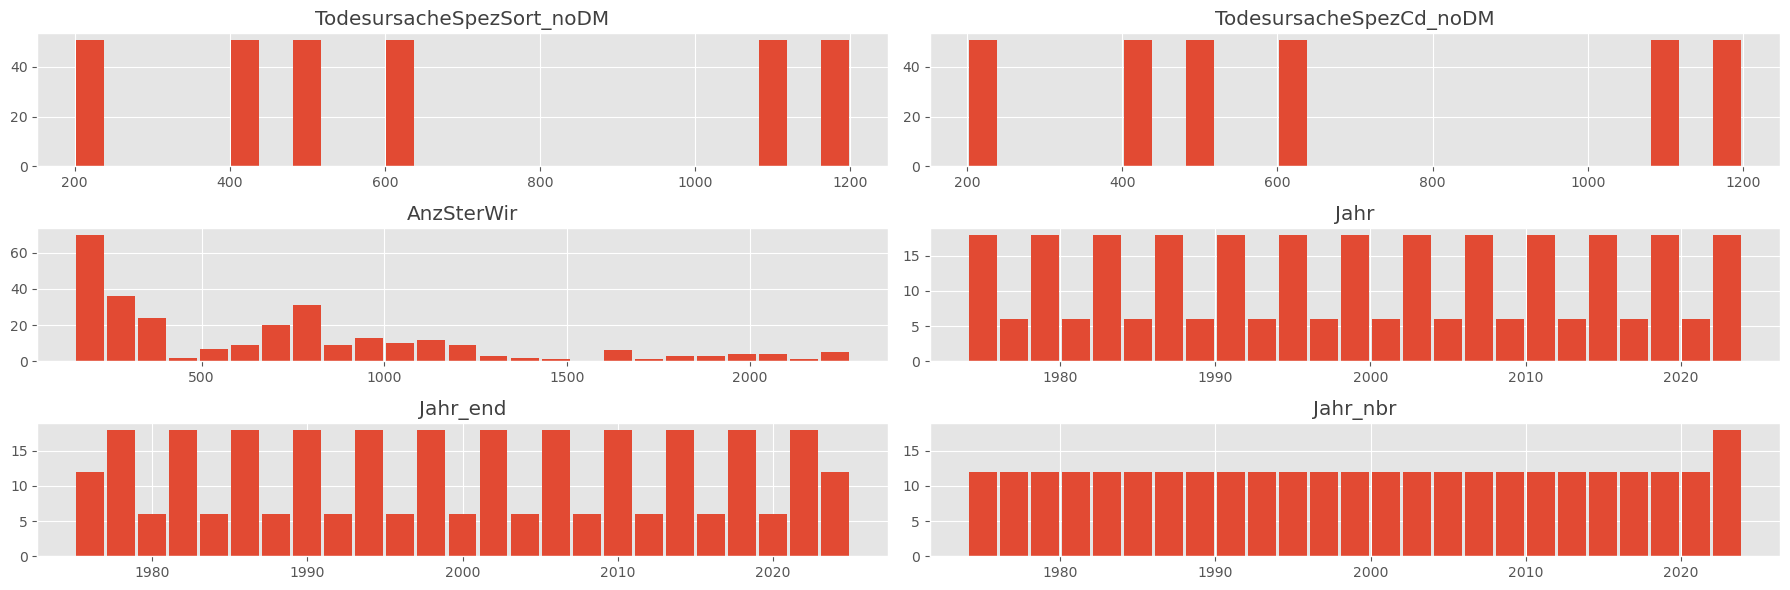

In [67]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [68]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,


### Nullwerte und Missings?

In [69]:
data2betested.isnull().sum()

TodesursacheSpezSort_noDM     0
TodesursacheSpezLang_noDM     0
TodesursacheSpezCd_noDM       0
AnzSterWir                   21
StichtagDatJahr_str           0
Jahr                          0
Jahr_end                      0
Jahr_nbr                      0
dtype: int64

In [70]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [71]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,Sum_AnzSterWir
0,2024-01-01,2024,2024-12-31,3063
1,2023-01-01,2023,2023-12-31,3106
2,2022-01-01,2022,2022-12-31,3350


In [72]:
agg_tdurs = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['TodesursacheSpezSort_noDM', 'TodesursacheSpezLang_noDM', 'TodesursacheSpezCd_noDM',]) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('TodesursacheSpezSort_noDM', ascending=True) 
agg_tdurs.reset_index().head(6)

,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,Sum_AnzSterWir
0,200,Krebskrankheiten,200,47474
1,400,Demenz,400,9667
2,500,Kreislaufsystem,500,78753
3,600,Atmungsorgane,600,10275
4,1100,Unfälle und Gewalteinwirkungen,1100,13258
5,1200,Alle übrigen Todesursachen,1200,36958


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wochenaufenthaltender nach Altersgruppe

In [73]:
myAgg1 = data2betested
myAgg1.reset_index().head(3)

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1974-01-01,200,Krebskrankheiten,200,1081,1974-01-01,1974-01-01,1974-12-31,1974
1,1974-01-01,1200,Alle übrigen Todesursachen,1200,642,1974-01-01,1974-01-01,1974-12-31,1974
2,1974-01-01,1100,Unfälle und Gewalteinwirkungen,1100,321,1974-01-01,1974-01-01,1974-12-31,1974


In [74]:
data2betested.columns

Index(['TodesursacheSpezSort_noDM', 'TodesursacheSpezLang_noDM', 'TodesursacheSpezCd_noDM',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [75]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "TodesursacheSpezLang_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Sterbefälle nach Todesursachen, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [76]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
#combined_chart = alt.vconcat(grafik1, grafik2, grafik3, spacing=20)
combined_chart = alt.vconcat(grafik1, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#999980",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [77]:
myFG = data2betested
myFG.head(2)

,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,
1974-01-01,200,Krebskrankheiten,200,1081,1974-01-01,1974-01-01,1974-12-31,1974
1974-01-01,1200,Alle übrigen Todesursachen,1200,642,1974-01-01,1974-01-01,1974-12-31,1974


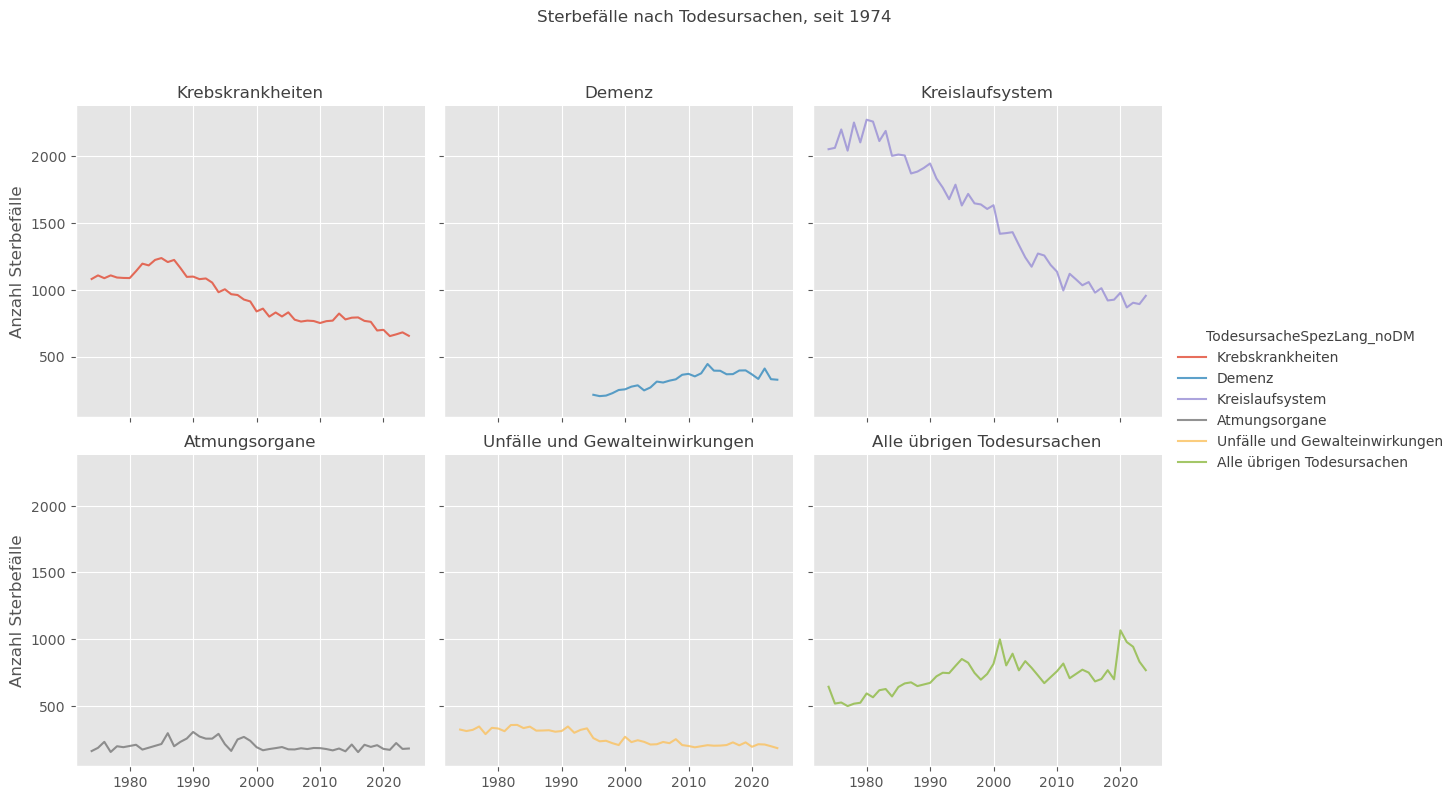

In [78]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('TodesursacheSpezSort_noDM', ascending=True)
    ,col = "TodesursacheSpezLang_noDM"
    ,hue = "TodesursacheSpezLang_noDM"
    ,col_wrap = 3
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzSterWir"
    ,ylabel= "Anzahl Sterbefälle"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Sterbefälle nach Todesursachen, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [79]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [80]:
data2betested.columns

Index(['TodesursacheSpezSort_noDM', 'TodesursacheSpezLang_noDM', 'TodesursacheSpezCd_noDM',
       'AnzSterWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [81]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['TodesursacheSpezLang_noDM'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Krebskrankheiten': '#0017BF', 'Alle übrigen Todesursachen': '#0072D7', 'Unfälle und Gewalteinwirkungen': '#00A5D2', 'Atmungsorgane': '#5E359A', 'Demenz': '#BA0062', 'Kreislaufsystem': '#DA5563'}


In [82]:
myTM = data2betested
myTM.reset_index().head(2)

,StichtagDatJahr,TodesursacheSpezSort_noDM,TodesursacheSpezLang_noDM,TodesursacheSpezCd_noDM,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1974-01-01,200,Krebskrankheiten,200,1081,1974-01-01,1974-01-01,1974-12-31,1974
1,1974-01-01,1200,Alle übrigen Todesursachen,1200,642,1974-01-01,1974-01-01,1974-12-31,1974


In [83]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['TodesursacheSpezLang_noDM', 'Jahr_nbr']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Sterbefälle nach Todesursache, seit "+data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000018C69FCFA10>, 'TodesursacheSpezLang_noDM', 'Jahr_nbr']
Typ von path: <class 'list'>


In [84]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['TodesursacheSpezLang_noDM', 'Jahr_nbr']
    ,values="AnzSterWir"
    ,color="TodesursacheSpezLang_noDM"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Sterbefälle nach Todesursache, seit "+data_min_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000018C69FE7210>, 'TodesursacheSpezLang_noDM', 'Jahr_nbr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=31&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------